#### Full Fine Tuning

Full Fine Tuning is very time consuming process. Here we are going to use very small LLM to understand the concept.

##### 1. Understanding Small Model for Fine Tuning

In [ ]:
# # run on Google Colab
# #%%capture
# ! pip install --upgrade pyarrow datasets torchao

In [1]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "false"
os.environ["PYTHONUTF8"]="1"
import torch
from transformers import pipeline

d:\ProjectDesk\gh-iamatulkumar-ya\data-science\.venv_llm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# using very small model
#model_id = "arnir0/Tiny-LLM"
#model_id="google/gemma-3-270m"
model_id="HuggingFaceTB/SmolLM2-135M"

In [3]:
llm_model = pipeline(
    "text-generation",
    model=model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto")

d:\ProjectDesk\gh-iamatulkumar-ya\data-science\.venv_llm\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Optimus\.cache\huggingface\hub\models--HuggingFaceTB--SmolLM2-135M. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 1

In [4]:
query="Happiness is not something ready made. It comes from"

In [5]:
llm_model(query)[0]["generated_text"]

[transformers] Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


'Happiness is not something ready made. It comes from within the heart.\n\nIt is through the heart that happiness is found.\n\nWe are all born with happiness inside us. And when we are happy, we tend to be happy. We tend to be happy because God is good. So if we are unhappy, we tend to be unhappy because God is bad. So it is possible to be happy in the midst of unhappiness.\n\nSo if we are happy, we tend to be happy and if we are unhappy, we tend to be unhappy.\n\nSo what is happiness?\n\nIt is the state of being happy.\n\nWe can be happy in a place where we do not have any possessions. We can have a lot of money, but we cannot have anything. We can have whatever we want, but we cannot have everything.\n\nSo happiness is the state of being happy, not having any possessions, not having anything.\n\nAnd we can be happy in a place where we have all the things that we want, but we cannot have everything.\n\nSo happiness is the state of being happy.\n\nAnd we are happy when we are in a situ

Perfect superfast, let's finetune with our Quotes data and see what response it gives once fully fine tuned

##### 2. Loading Model Configs

In [6]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import SFTConfig, SFTTrainer

In [7]:
# loading model tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)

# setting padding
tokenizer.pad_token = tokenizer.eos_token

In [8]:
# loading base model
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    dtype=torch.bfloat16

)

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 8905.87it/s]


##### 3. Defining SFTConfig and Trainer for Training

In [11]:
# adding sft config

sft_config = SFTConfig(
    output_dir="./full-fine-tune-training",  # The file path where the model checkpoints, tokenizer files, and training logs will be saved.
    dataset_text_field="text", # Tells the trainer which specific column name in your dataset contains the text to be trained on.
    packing=False, # If true, it combines multiple short examples into a single sequence of
    per_device_train_batch_size=4, # The number of training examples processed simultaneously on a single GPU.
    gradient_accumulation_steps=4, # The number of steps to wait (accumulating gradients) before performing a single weight update, effectively increasing the "total" batch size.
    learning_rate=3e-5, # The "step size" the optimizer takes to minimize the error; too high may cause instability, too low may be too slow.
    num_train_epochs=2, # The total number of times the model will see the entire training dataset.
    save_steps=100, # How often (in training steps) the trainer saves a backup checkpoint of the model to the output directory.
    logging_steps=10, # How frequently the training progress (loss, learning rate, etc.) is printed to the console or log.
    lr_scheduler_type="cosine", # Defines how the learning rate changes over time (e.g., "cosine" smoothly reduces the rate towards the end of training).
    #optim="paged_adamw_32bit", # The specific optimization algorithm used; paged_adamw_32bit is memory-efficient and ideal for QLoRA.
    report_to="none", # Specifies external platforms (like Weights & Biases or TensorBoard) where training metrics should be sent for visualization.
    use_cpu=True,
    completion_only_loss=True,
)

loading dataset

In [ ]:
# # mounting google drive such that we can use the files for ingest
# from google.colab import drive
# drive.mount('/content/drive')

# dataset_file_path = "/content/drive/MyDrive/Colab Notebooks/instruction_fine_tuning/full_fine_tuning_training_data.json"

In [10]:
# local file path
dataset_file_path = os.path.join(os.getcwd(), "full_fine_tuning_training_data.json")

In [12]:
# laoding dataset
from datasets import load_dataset
#dataset = Dataset.from_text(dataset_file_path)
dataset = load_dataset("json", data_files=dataset_file_path, split="train")


Generating train split: 952 examples [00:00, 77259.01 examples/s]


In [13]:
print(dataset[0]["text"])

Quote: To be, or not to be,
Author: William Shakespeare
Source: Hamlet
Completion: that is the question


In [14]:
# initilizing SFTTrainer

trainer = SFTTrainer(
    model=model_id,
    args=sft_config,
    train_dataset=dataset,
    processing_class=tokenizer
)

Tokenizing train dataset: 100%|██████████| 952/952 [00:00<00:00, 6354.74 examples/s]


In [15]:
# let's see how many paramter trainer will be fine tuning
trainer.get_num_trainable_parameters()

134515008

In [16]:
# total model paramters
model.num_parameters()

134515008

as this is full fine tuning, all paramters will get updated,

##### 4. Train and Save

In [17]:
# training the model
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 0}.


Step,Training Loss
10,3.388183
20,2.202157
30,1.939135
40,1.854760
50,1.829279
60,1.849247
70,1.643391
80,1.617997
90,1.621846
100,1.649439


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.41it/s]


TrainOutput(global_step=120, training_loss=1.9080204963684082, metrics={'train_runtime': 23613.305, 'train_samples_per_second': 0.081, 'train_steps_per_second': 0.005, 'total_flos': 51184118398464.0, 'train_loss': 1.9080204963684082})

In [18]:
# checking training state
trainer.state

TrainerState(epoch=2.0, global_step=120, max_steps=120, logging_steps=10, eval_steps=500, save_steps=100, train_batch_size=4, num_train_epochs=2, num_input_tokens_seen=0, total_flos=51184118398464.0, log_history=[{'loss': 3.388182830810547, 'grad_norm': 5.605096817016602, 'learning_rate': 2.958554880596515e-05, 'entropy': 3.5141878187656403, 'num_tokens': 5561.0, 'mean_token_accuracy': 0.43185984417796136, 'epoch': 0.16806722689075632, 'step': 10}, {'loss': 2.202156829833984, 'grad_norm': 3.473980188369751, 'learning_rate': 2.818225668992948e-05, 'entropy': 2.311596614122391, 'num_tokens': 11007.0, 'mean_token_accuracy': 0.5863067805767059, 'epoch': 0.33613445378151263, 'step': 20}, {'loss': 1.9391351699829102, 'grad_norm': 3.0194051265716553, 'learning_rate': 2.5880615565184318e-05, 'entropy': 2.0021921902894975, 'num_tokens': 16329.0, 'mean_token_accuracy': 0.6353931874036789, 'epoch': 0.5042016806722689, 'step': 30}, {'loss': 1.8547603607177734, 'grad_norm': 2.8851723670959473, 'lea

In [19]:
# This prints the loss and learning rate for every logging step
for log in trainer.state.log_history:
    if 'loss' in log:
        print(f"Step: {log['step']} | Loss: {log['loss']:.4f} | LR: {log['learning_rate']:.8f}")

Step: 10 | Loss: 3.3882 | LR: 0.00002959
Step: 20 | Loss: 2.2022 | LR: 0.00002818
Step: 30 | Loss: 1.9391 | LR: 0.00002588
Step: 40 | Loss: 1.8548 | LR: 0.00002284
Step: 50 | Loss: 1.8293 | LR: 0.00001926
Step: 60 | Loss: 1.8492 | LR: 0.00001539
Step: 70 | Loss: 1.6434 | LR: 0.00001150
Step: 80 | Loss: 1.6180 | LR: 0.00000784
Step: 90 | Loss: 1.6218 | LR: 0.00000467
Step: 100 | Loss: 1.6494 | LR: 0.00000221
Step: 110 | Loss: 1.6360 | LR: 0.00000062
Step: 120 | Loss: 1.6648 | LR: 0.00000001


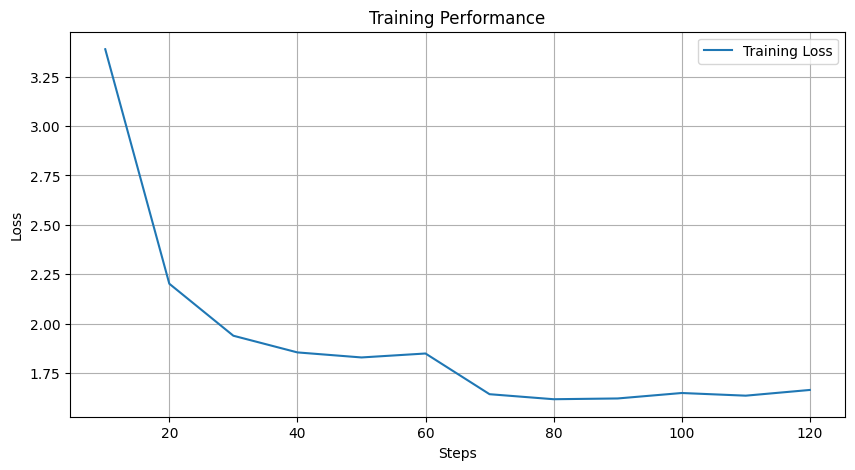

In [20]:
# loss curve
import matplotlib.pyplot as plt

# Extract steps and loss values
steps = [log['step'] for log in trainer.state.log_history if 'loss' in log]
losses = [log['loss'] for log in trainer.state.log_history if 'loss' in log]

plt.figure(figsize=(10, 5))
plt.plot(steps, losses, label='Training Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Performance')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# TensorBoard to look into the training stats
%load_ext tensorboard
%tensorboard --logdir runs

In [ ]:
# saving into drive
#trainer.save_model("/content/drive/MyDrive/Colab Notebooks/instruction_fine_tuning/full-fine-tuned-model")

In [24]:
# saving the model
trainer.save_model("./full-fine-tuned-model")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.29it/s]


##### 5. Let's Load and Check Fine Tuned Model

In [25]:
fine_tuned_model_id="./full-fine-tuned-model"

In [26]:
# loading fully fine tuned model
ft_model = AutoModelForCausalLM.from_pretrained(fine_tuned_model_id)
ft_tokenizer = AutoTokenizer.from_pretrained(fine_tuned_model_id)

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 8142.30it/s]


In [27]:
# let's check the response
input = f"Quote: {query}\nAuthor: Confucius\nSource: Attributed\nCompletion:"
input_token = ft_tokenizer(input, return_tensors="pt")["input_ids"]

output = ft_model.generate(input_token,
                           max_new_tokens=60,
                           repetition_penalty=1.2,
                           eos_token_id=tokenizer.eos_token_id,
                            pad_token_id=tokenizer.eos_token_id)
tokenizer.batch_decode(output)

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


['Quote: Happiness is not something ready made. It comes from\nAuthor: Confucius\nSource: Attributed\nCompletion: the way you live<|endoftext|>']

Hmm, not impressing but still able to return what we were a bit expecting.

Accuracy and performance depends upon the model and the training. As we did this training on local machine thus had to reduce some parameters which cuases this behaviour.

In [ ]:
# exporting required libs
!pip freeze > requirements.txt